This notebook compares the dist change of different embedding methods, namely `Gaussian Embedding(GE)`, `scVI/VAE`, `Diffusion map(DF)`, `UMAP`, `t-SNE`. We compute the `Coefficient of Variation(CV)` of dist_embedding/dist_original for each edges in KNN constructed in the original space. **Small CV implicates low variation of the dist ratio, thus methods with small CV preserves the local metric better.**

## **Defaults**

In [3]:
import os
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scvi
import scvelo as scv
from scipy.sparse import csr_matrix
from utils import kde_lowess

/home/sirin/anaconda3/envs/scvi_scv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_path='data/'
# ellipsoid, saddle, fourwell
data_name = 'sphere'

In [5]:
# Parameters: k_nei for KNN, L for latent dimension, seed for random seed
[k_nei, K, L, seed] = [10, 2, 3, 0]

random.seed(seed)
result_path = 'cvresults/'+data_name+str([k_nei, L, seed])+'/'
figure_path = result_path
cmap = plt.colormaps['Spectral_r']

folder = os.path.exists(result_path)
if not folder:                   
    os.makedirs(result_path)  

## **Data generation**

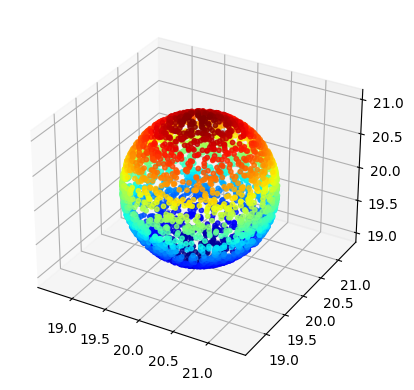

In [6]:
if data_name == 'ellipsoid':
    n_samples=3000

    g3 = np.random.randn(3,n_samples)
    gr = np.linalg.norm(g3,axis=0)

    x1,x2,x3 = 4*g3/gr
    x2 = 4*x2

    color_label=np.zeros((n_samples))
    color_label[np.argsort(x3)]=np.arange(n_samples)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x1+20, x2+20, x3+20,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    # ax.set_aspect('equal')
    # ax.set_xlim((-2,2))
    # ax.set_ylim((-2,2))
    # ax.set_zlim((-2,2))
    plt.axis('equal')
    plt.show()

    X_major=np.array([x1,x2,x3]).T
    X_minor=0.2*np.random.randn(n_samples,7)
    X=np.hstack((X_major,X_minor))+20

elif data_name == 'sphere':
    n_samples=3000

    g3 = np.random.randn(3,n_samples)
    gr = np.linalg.norm(g3,axis=0)

    x1,x2,x3 = g3/gr
    x2 = x2

    color_label=np.zeros((n_samples))
    color_label[np.argsort(x3)]=np.arange(n_samples)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x1+20, x2+20, x3+20,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    # ax.set_aspect('equal')
    # ax.set_xlim((-2,2))
    # ax.set_ylim((-2,2))
    # ax.set_zlim((-2,2))
    plt.axis('equal')
    plt.show()

    X_major=np.array([x1,x2,x3]).T+20
    X_minor=0.2*np.random.randn(n_samples,7)
    X=np.hstack((X_major,X_minor))

elif data_name == 'saddle':
    n_samples=3000
    X_minor=0.1*np.random.randn(n_samples,7)

    roi=np.linspace(-5,5,10000)

    x1=np.random.choice(roi,n_samples)
    x2=np.random.choice(roi,n_samples)
    color_label=np.zeros((n_samples))
    color_label[np.argsort(x2)]=np.arange(n_samples)

    x3=1*((x1)**2 - (x2)**2)


    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # ax.scatter(x1, x2, x3,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    ax.scatter(x1, x2, x3,  s=10, c=x3,alpha=0.8,cmap='viridis')
    plt.show()

    X_major=np.array([x1,x2,x3]).T
    X=np.hstack((X_major,X_minor))+40

elif data_name == 'fourwell':
    # Define the double well potential function
    def four_well_potential(x, y):
        # return 0.05*x**4-x**2+0.05*y**4-(y-0.5)**2
        return 0.05*x**4-x**2+0.05*y**4-y**2

    # Define the range of x and y values to plot


    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)

    # Create a 2D grid of x and y values
    X, Y = np.meshgrid(x, y)

    # Calculate the potential energy at each point in the grid
    Z = four_well_potential(X, Y)

    # Define the parameters of the simulation
    k1 = 0.05  
    k2= 0.05
    T = 0.8  # Temperature
    gamma = 0.1  # Damping coefficient
    dt = 0.01  # Time step
    tmax = 100.0  # Maximum simulation time
    x0 = np.array([0, 0.0])  # Initial position

    # Define the double well potential
    def potential(x):
        return k1*x[0]**4-x[0]**2+k2*x[1]**4-(x[1]-0.5)**2

    # Define the gradient of the potential
    def gradient(x):
        return np.array([4*k1*x[0]**3-2*x[0],4*k2*x[1]**3-2*x[1]+1])

    # Define the stochastic force
    def stochastic_force(x):
        return 0.08*np.sqrt(2.0 * gamma * T / dt) * np.random.normal(size=2)

    # Initialize the particle position and velocity


    # Initialize the time and trajectory arrays

    trajs=[]

    for tl in range(60):
        # Perform the simulation using the Euler-Maruyama method
        
        x = x0
        v = np.zeros(2)
        t = np.arange(0.0, tmax, dt)
        
        tr = np.zeros((len(t), 2))
        tr[0] = x
        
        tr_U= np.zeros((len(t), 1))
        tr_U[0]=potential(x)

        for i in range(1, len(t)):
            # Calculate the deterministic force
            f_d = -gradient(x)

            # Calculate the stochastic force
            f_s = stochastic_force(x)

            # Calculate the position using the Euler method
            x += (f_d*dt + f_s)

            # Update the trajectory array
            tr[i] = x
            tr_U[i] = potential(x)
            
        
        #trajs.append(tr[::200, :])

        trajs.append(np.hstack((tr[::200, :],tr_U[::200,:])))
        # Plot the trajectory of the particle
        plt.scatter(tr[::200, 0], tr[::200, 1],s=1)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Trajectory of Particle in Double Well Potential')
    plt.show()

    X_major=np.concatenate(trajs,axis=0)

    X_major = X_major[X_major[:,2]<=6,:]

    n_samples=X_major.shape[0]

    X_minor=0.1*np.random.randn(n_samples,8)
    X=np.hstack((X_major,X_minor))+30
    color_label=np.zeros((n_samples))
    color_label[np.argsort(X[:,0])]=np.arange(n_samples)

In [7]:
import anndata
adata = anndata.AnnData(X)

## **PCA, UMAP, t-SNE**

In [8]:
sc.pp.pca(adata, n_comps=3)
sc.pp.neighbors(adata, n_neighbors=k_nei)
sc.tl.umap(adata)
sc.tl.tsne(adata)

In [9]:
gene_arr=adata.var.index.values
X_pca=adata.obsm['X_pca']
X_umap=adata.obsm['X_umap']
X_tsne=adata.obsm['X_tsne']

## **DF**

In [10]:
# Use alpha=1 kernel

eps = 30 # tunning hyperparameter!!! Gaussian width
alpha = 1

XXT = X@X.T # i,j-element is the inner prod of i,j rows of X
X2 = np.array([np.sum(X**2,axis=1),])

D2 = X2 + X2.T - 2*XXT # i,j-element is the square Euclidean distance of the i,j rows of X 
D2 = D2*(D2 >= 0) # to avoid numerical error
D = np.sqrt(D2) # pairwise Euclidean distances

kernel = np.exp(-D2/eps) # Graph-Laplacian where alpha = 0

q = np.array([np.sum(kernel,axis=1),])
q = q**alpha
K_alpha = kernel/(q.T@q)

p = np.zeros_like(K_alpha)
d_alpha = np.sum(K_alpha,axis=1)
for i in range(len(d_alpha)):
    p[i,:] = K_alpha[i,:]/d_alpha[i]

# p is the Markov matrix

# compute the eigen decomposition of p
eigs, eigvecs = np.linalg.eig(p)

# use 1 step transition is ok
X_diff = eigvecs[:,1:4]@np.diag(eigs[1:4])

## **scVI**

In [11]:
scvi.model.SCVI.setup_anndata(adata)
VAE = scvi.model.SCVI(adata=adata)
VAE.train()
X_scvi = VAE.get_latent_representation()

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 400/400: 100%|██████████| 400/400 [00:51<00:00,  8.86it/s, v_num=1, train_loss_step=9.58, train_loss_epoch=9.13]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [00:51<00:00,  7.81it/s, v_num=1, train_loss_step=9.58, train_loss_epoch=9.13]


## **GE**

In [12]:
row = np.array([np.ones((k_nei,))*i for i in range(adata.shape[0])]).flatten()
col = (adata.obsp['distances']+csr_matrix(np.eye(adata.obsp['distances'].shape[0]))).indices
w_val = np.array([np.linalg.norm(X_pca[int(i),:]-X_pca[int(j),:]) for i,j in zip(row,col)])
adj_val = np.ones(col.shape)
A = csr_matrix((adj_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
W_mat = csr_matrix((w_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))

In [13]:
from g2g_model_Fisher import *
from utils import *
import torch
import torch.nn as nn
import torch.optim as optim

epochs = 400
nsamples = 5
learning_rate = 1e-3
seed = 0
# n_workers = 4

A=A.astype(np.float32)
X=X.astype(np.float32)

if seed is not None:
    reset_seeds(seed)

z=X[:,0]

n = A.shape[0]
train_nodes, val_nodes = train_test_split(n, train_ratio=1.0)
A_train = A[train_nodes, :][:, train_nodes]
X_train = X[train_nodes]
z_train = z[train_nodes]
A_val = A[val_nodes, :][:, val_nodes]
X_val = X[val_nodes]
z_val = z[val_nodes]

train_data = AttributedGraph(A_train, X_train, z_train, K)
val_data = AttributedGraph(A_val, X_val, z_val, K)

encoder = Encoder(X.shape[1], L)

In [14]:
optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)

iterations = epochs #// n_workers
dataset = GraphDataset(train_data, nsamples, iterations)
loader = DataLoader(
    dataset,
    batch_size=1,
#     num_workers=n_workers,
    worker_init_fn=reset_seeds,
    collate_fn=lambda args: args,
)

In [15]:
for batch_idx, data in enumerate(loader):
    encoder.train()
    optimizer.zero_grad()

    loss = encoder.compute_loss(data[0][0],data[0][1],data[0][2],data[0][3],data[0][4],data[0][5])
    if batch_idx% 10 == 0:
        print(batch_idx,loss)
    loss.backward()
    optimizer.step()

0 tensor(1.5568e+09, grad_fn=<DivBackward0>)
10 tensor(2.3423e+08, grad_fn=<DivBackward0>)
20 tensor(2.2421e+08, grad_fn=<DivBackward0>)
30 tensor(2.1420e+08, grad_fn=<DivBackward0>)
40 tensor(2.1353e+08, grad_fn=<DivBackward0>)
50 tensor(2.1211e+08, grad_fn=<DivBackward0>)
60 tensor(2.1278e+08, grad_fn=<DivBackward0>)
70 tensor(2.1322e+08, grad_fn=<DivBackward0>)
80 tensor(2.1142e+08, grad_fn=<DivBackward0>)
90 tensor(2.1027e+08, grad_fn=<DivBackward0>)
100 tensor(2.1092e+08, grad_fn=<DivBackward0>)
110 tensor(2.1157e+08, grad_fn=<DivBackward0>)
120 tensor(2.1096e+08, grad_fn=<DivBackward0>)
130 tensor(2.1027e+08, grad_fn=<DivBackward0>)
140 tensor(2.1180e+08, grad_fn=<DivBackward0>)
150 tensor(2.1040e+08, grad_fn=<DivBackward0>)
160 tensor(2.1062e+08, grad_fn=<DivBackward0>)
170 tensor(2.1050e+08, grad_fn=<DivBackward0>)
180 tensor(2.0944e+08, grad_fn=<DivBackward0>)
190 tensor(2.1135e+08, grad_fn=<DivBackward0>)
200 tensor(2.1151e+08, grad_fn=<DivBackward0>)
210 tensor(2.1065e+08, g

In [16]:
mu, sigma = encoder(torch.tensor(X))
X_mu = mu.detach().numpy()
X_sigma = sigma.detach().numpy()

## **Calcualte distance pair**

In [17]:
def Fisher_dist(mu1,sigma1,mu2,sigma2):
    dim=len(mu1)
    dF2=0
    for i in range(dim):
        a=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)+\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        b=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)-\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        
        dF2+=2*(np.log(a/b))**2
    dF=np.sqrt(dF2)
    return dF

In [18]:
dist_ratios_Ge=[]
dist_ratios_umap = []
dist_ratios_tsne = []
dist_ratios_df = []
dist_ratios_vae = []
Lvae = X_scvi.shape[1]//2

for inds in np.split(A.indices, A.indptr)[1:-1]:

    dist_r_Ge = []
    dist_r_umap = []
    dist_r_tsne = []
    dist_r_df = []
    dist_r_vae = []
    self_ind=inds[0]
    for nei_k in range(1,len(inds)):
        
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dumap=np.linalg.norm(X_umap[self_ind,:]-X_umap[inds[nei_k],:])
        dtsne=np.linalg.norm(X_tsne[self_ind,:]-X_tsne[inds[nei_k],:])
        ddf=np.linalg.norm(X_diff[self_ind,:]-X_diff[inds[nei_k],:])
        dGe=Fisher_dist(X_mu[self_ind,:],X_sigma[self_ind,:],\
                        X_mu[inds[nei_k],:],X_sigma[inds[nei_k],:])
        dvae=Fisher_dist(X_scvi[self_ind,:Lvae],np.exp(X_scvi[self_ind,Lvae:]/2),\
                        X_scvi[inds[nei_k],:Lvae],np.exp(X_scvi[inds[nei_k],Lvae:]/2))


        dist_r_Ge.append(dEu/dGe)
        dist_r_umap.append(dEu/dumap)
        dist_r_tsne.append(dEu/dtsne)
        dist_r_df.append(dEu/ddf)
        dist_r_vae.append(dEu/dvae)

        
        
#     print(np.std(dist_r)/np.mean(dist_r))
    
    dist_ratios_Ge.append(np.std(dist_r_Ge)/np.mean(dist_r_Ge))
    dist_ratios_umap.append(np.std(dist_r_umap)/np.mean(dist_r_umap))
    dist_ratios_tsne.append(np.std(dist_r_tsne)/np.mean(dist_r_tsne))
    dist_ratios_df.append(np.std(dist_r_df)/np.mean(dist_r_df))
    dist_ratios_vae.append(np.std(dist_r_vae)/np.mean(dist_r_vae))

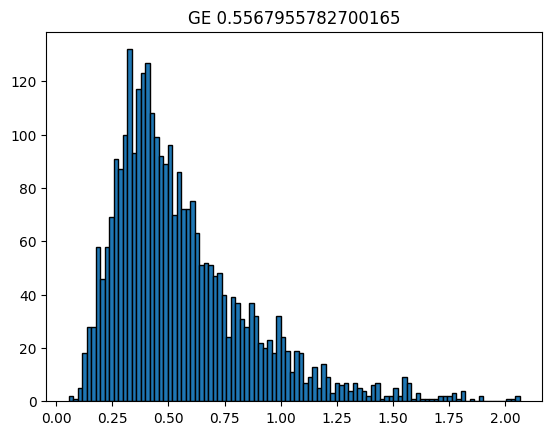

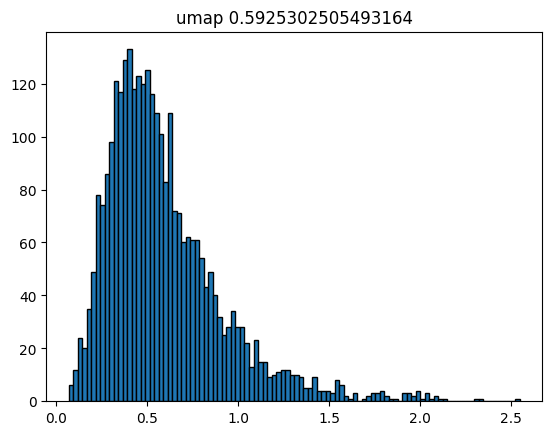

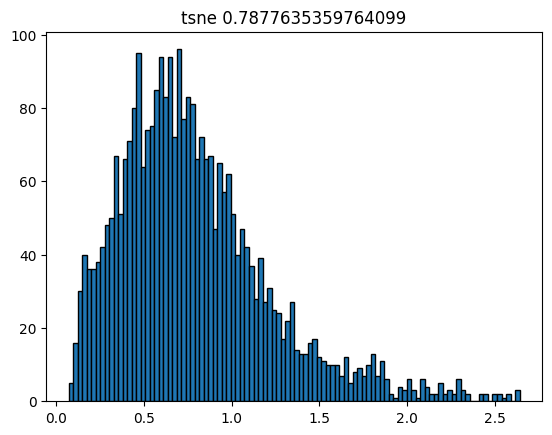

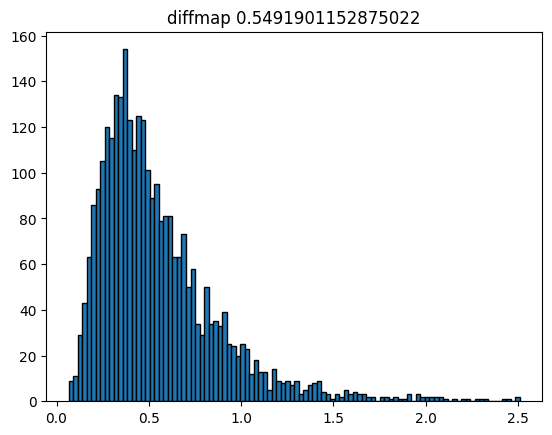

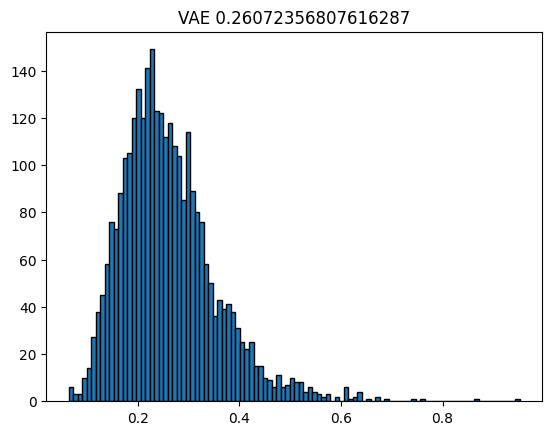

In [19]:
plt.hist(np.array(dist_ratios_Ge),bins=100,edgecolor='black')
plt.title(f'GE {np.mean(dist_ratios_Ge)}')
plt.savefig(result_path+'GE')
plt.show()

plt.hist(np.array(dist_ratios_umap),bins=100,edgecolor='black')
plt.title(f'umap {np.mean(dist_ratios_umap)}')
plt.savefig(result_path+'UMAP')
plt.show()

plt.hist(np.array(dist_ratios_tsne),bins=100,edgecolor='black')
plt.title(f'tsne {np.mean(dist_ratios_tsne)}')
plt.savefig(result_path+'tSNE')
plt.show()

plt.hist(np.array(dist_ratios_df),bins=100,edgecolor='black')
plt.title(f'diffmap {np.mean(dist_ratios_df)}')
plt.savefig(result_path+'DF')
plt.show()

plt.hist(np.array(dist_ratios_vae),bins=100,edgecolor='black')
plt.title(f'VAE {np.mean(dist_ratios_vae)}')
plt.savefig(result_path+'VAE')
plt.show()